In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model building
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load your dataset
df = pd.read_csv("eng.2.csv")

# Preview data
df.head()

,Round,Date,Team 1,FT,Team 2
0,1,Fri Sep 11 2020,Watford FC,1-0,Middlesbrough FC
1,1,Sat Sep 12 2020,Birmingham City FC,1-0,Brentford FC
2,1,Sat Sep 12 2020,Wycombe Wanderers FC,0-1,Rotherham United FC
3,1,Sat Sep 12 2020,AFC Bournemouth,3-2,Blackburn Rovers FC
4,1,Sat Sep 12 2020,Bristol City FC,2-1,Coventry City FC


In [3]:
# Basic info
df.info()

# Check missing values
df.isnull().sum()

# Summary stats
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 552 entries, 0 to 551
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Round   552 non-null    int64
 1   Date    552 non-null    str  
 2   Team 1  552 non-null    str  
 3   FT      132 non-null    str  
 4   Team 2  552 non-null    str  
dtypes: int64(1), str(4)
memory usage: 47.3 KB


,Round
count,552.00000
mean,23.50000
std,13.28796
min,1.00000
25%,12.00000
50%,23.50000
75%,35.00000
max,46.00000


In [5]:
df = pd.get_dummies(df, drop_first=True)

In [7]:
import numpy as np
from sklearn.model_selection import train_test_split

X = np.array([[1, 2], [3, 4], [5, 6]])
y = np.array([0, 1, 0])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       0.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



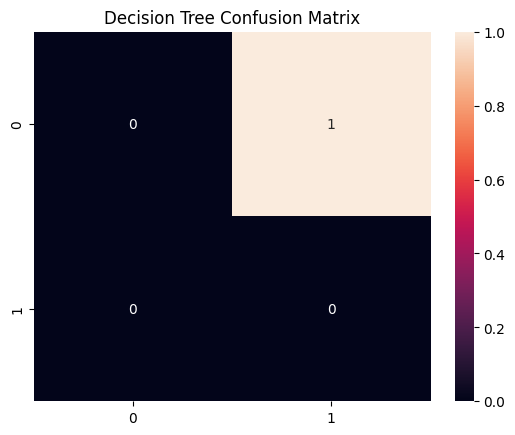

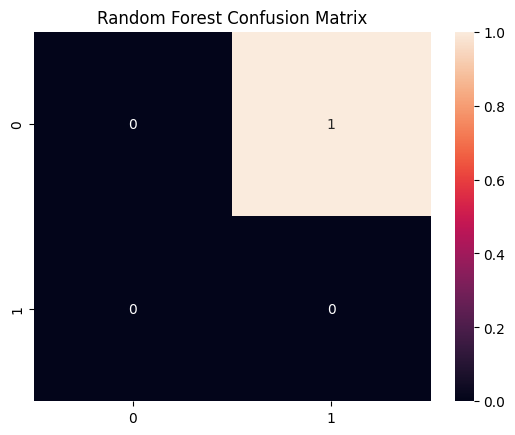

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create models
dt_model = DecisionTreeClassifier()
rf_model = RandomForestClassifier()

# Train models
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Generate predictions
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# Decision Tree
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.show()

# Random Forest
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

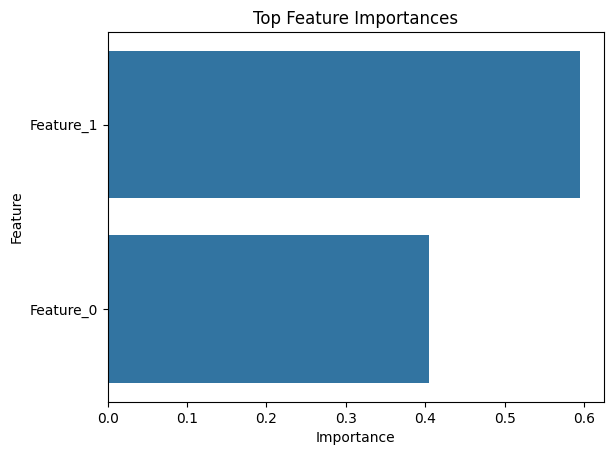

In [15]:
importances = rf_model.feature_importances_
features = [f'Feature_{i}' for i in range(X.shape[1])]  # fallback

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feat_df.head(10))
plt.title("Top Feature Importances")
plt.show()